In [1]:
import matplotlib.pyplot as pl
import numpy as np

In [2]:
data = np.load("./Cluster_results/nufft_vs_strobo_data.npy", allow_pickle=True)

In [3]:
nufft_arr = data[:,0]
strobo_arr = data[:,1]

In [6]:
strobo_arr[0]['time']

0.9479474465052287

In [4]:
freq_grid = np.reshape([nufft_arr[i]['inj_freq'] for i in range(len(nufft_arr))], (20,20))
mass_grid = np.reshape([np.log10(nufft_arr[i]['inj_mass']/2e30) for i in range(len(nufft_arr))], (20,20))
nufft_power = np.reshape([nufft_arr[i]['power'] for i in range(len(nufft_arr))], (20,20))
strobo_power = np.reshape([strobo_arr[i]['power'] for i in range(len(nufft_arr))], (20,20))

strobo_freqErr = np.reshape([np.abs(strobo_arr[i]['inj_freq'] - strobo_arr[i]['peak_f']) for i in range(len(nufft_arr))], (20,20))
nufft_freqErr = np.reshape([np.abs(nufft_arr[i]['inj_freq'] + nufft_arr[i]['peak_f']) for i in range(len(nufft_arr))], (20,20))

timing_ratio = [nufft_arr[i]['time']/strobo_arr[i]['time'] for i in range(len(nufft_arr))]

Text(0.5, 1.0, 'Ratio of computation time for nufft vs strobo (axis labels not done)')

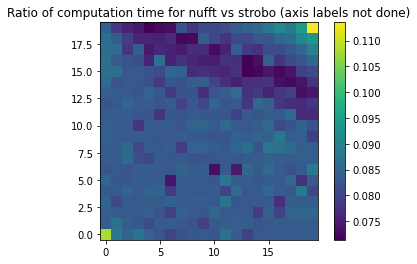

In [15]:
timing_ratio = np.reshape(timing_ratio, (20,20))
pl.imshow(timing_ratio, interpolation='none', origin = 'lower')
pl.colorbar()
pl.title("Ratio of computation time for nufft vs strobo (axis labels not done)")

Text(0.5, 1.0, 'Absolute error of the frequency (nufft)')

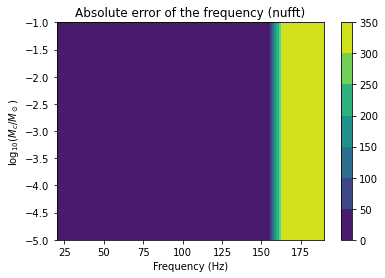

In [42]:
pl.contourf(freq_grid, mass_grid, strobo_freqErr)
pl.colorbar()
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'log$_{10}(M_c/M_\odot$)')
pl.title('Absolute error of the frequency (nufft)')

Text(0.5, 1.0, 'Absolute error of the frequency (nufft)')

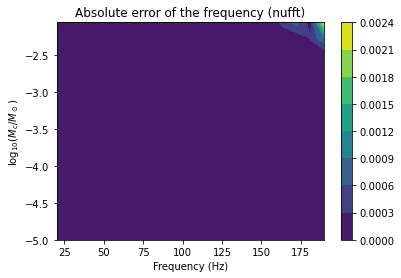

In [47]:
pl.contourf(freq_grid[:-5], mass_grid[:-5], nufft_freqErr[:-5])
pl.colorbar()
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'log$_{10}(M_c/M_\odot$)')
pl.title('Absolute error of the frequency (nufft)')

Text(0.5, 1.0, 'Power of the peak calculated by strobo')

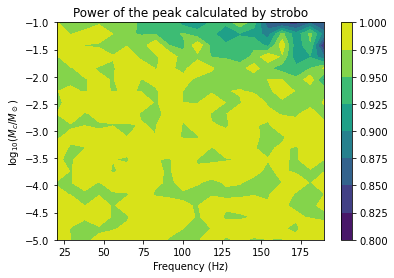

In [27]:
pl.contourf(freq_grid, mass_grid, strobo_power)
pl.colorbar()
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'log$_{10}(M_c/M_\odot$)')
pl.title('Power of the peak calculated by strobo')

Text(0.5, 1.0, 'Power of the peak calculated by nufft')

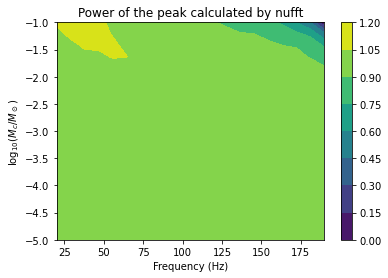

In [20]:
pl.contourf(freq_grid, mass_grid, nufft_power)
pl.colorbar()
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'log$_{10}(M_c/M_\odot$)')
pl.title('Power of the peak calculated by nufft')

In [49]:
nufft_arr[-20]['power']

1.0886275991011396

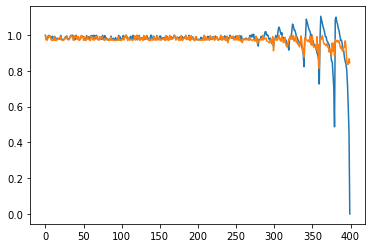

In [9]:
pl.plot([nufft_arr[i]['power'] for i in range(len(nufft_arr))])
pl.plot([strobo_arr[i]['power'] for i in range(len(strobo_arr))])

In [22]:
np.std([nufft_arr[i]['time']/strobo_arr[i]['time'] for i in range(len(nufft_arr))])

0.004244336133135468

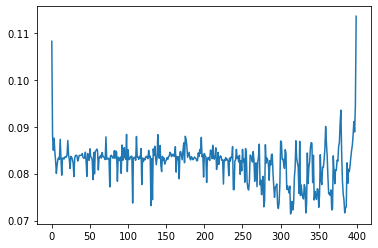

In [10]:
pl.plot([nufft_arr[i]['time']/strobo_arr[i]['time'] for i in range(len(nufft_arr))])
# pl.plot([ for i in range(len(strobo_arr))])

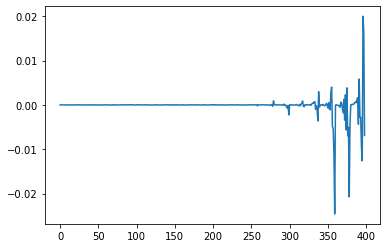

In [11]:
pl.plot([nufft_arr[i]['peak_f'] + nufft_arr[i]['inj_freq'] for i in range(len(nufft_arr))][:-1])
# pl.plot([ for i in range(len(strobo_arr))])

In [26]:
np.median(np.abs([nufft_arr[i]['peak_f'] + nufft_arr[i]['inj_freq'] for i in range(len(nufft_arr))][:-1]))

3.0500765029729814959e-05